In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("reseñas_con_sentimiento.csv")
print(df.head())

   rating                                         comentario  \
0       4                                                NaN   
1       3  El dia en concreto que fuimos pedimos un bocad...   
2       1  Atención de los camareras muy bueno,pero la co...   
3       4                                                NaN   
4       5  El sábado, fuimos a comer unas amigas y comimo...   

   review_timestamp                 date       fecha       fuente  \
0      1.775902e+09  2026-04-11 10:04:10  2026-04-11  google_maps   
1      1.774603e+09  2026-03-27 09:24:41  2026-03-27  google_maps   
2      1.773846e+09  2026-03-18 14:52:19  2026-03-18  google_maps   
3      1.772963e+09  2026-03-08 09:39:15  2026-03-08  google_maps   
4      1.772450e+09  2026-03-02 11:13:19  2026-03-02  google_maps   

                                    comentario_clean  sentiment_stars  \
0                                                NaN              NaN   
1  el dia en concreto que fuimos pedimos un bocad...  

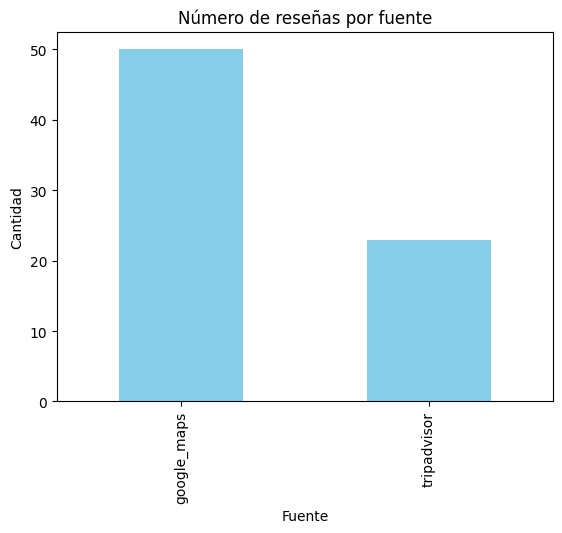

In [3]:
import matplotlib.pyplot as plt

df["fuente"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Número de reseñas por fuente")
plt.xlabel("Fuente")
plt.ylabel("Cantidad")
plt.show()


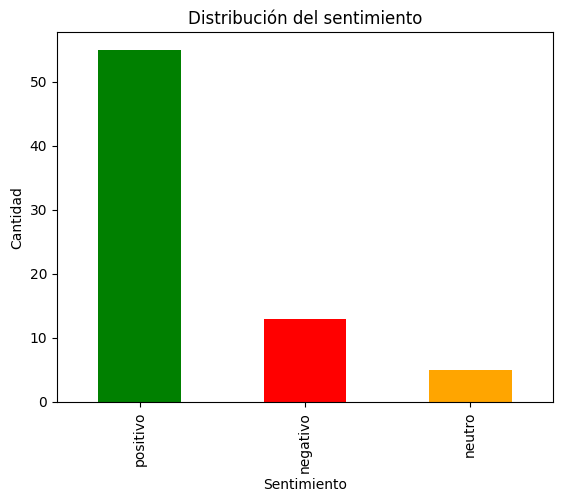

In [4]:
df["sentiment_label"].value_counts().plot(kind="bar", color=["green", "red", "orange"])
plt.title("Distribución del sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()


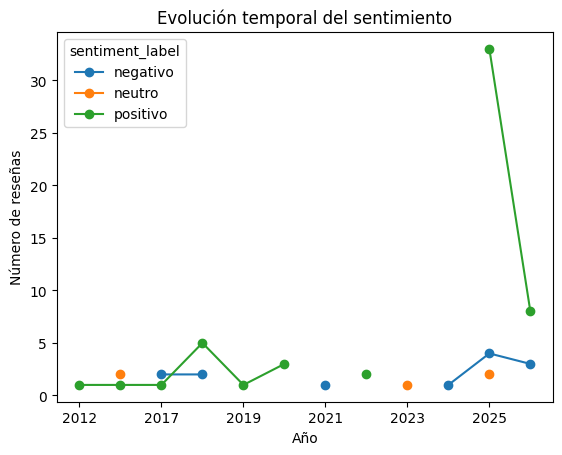

In [5]:
df["año"] = df["fecha"].astype(str).str[:4]
df.groupby(["año", "sentiment_label"]).size().unstack().plot(kind="line", marker="o")
plt.title("Evolución temporal del sentimiento")
plt.xlabel("Año")
plt.ylabel("Número de reseñas")
plt.show()

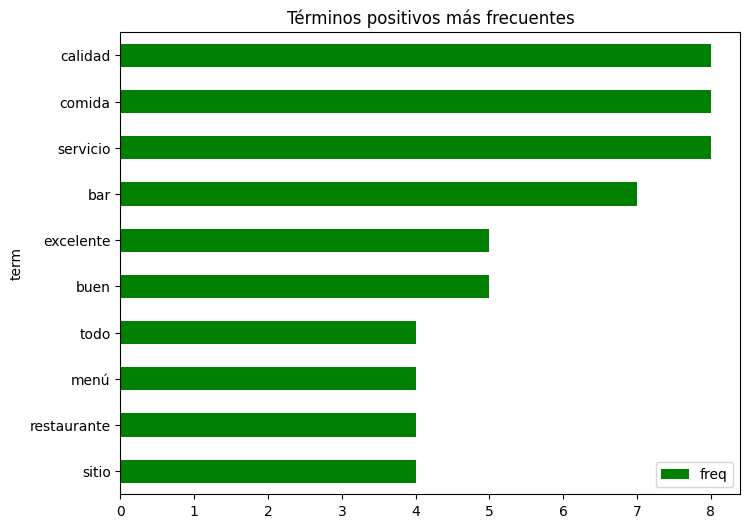

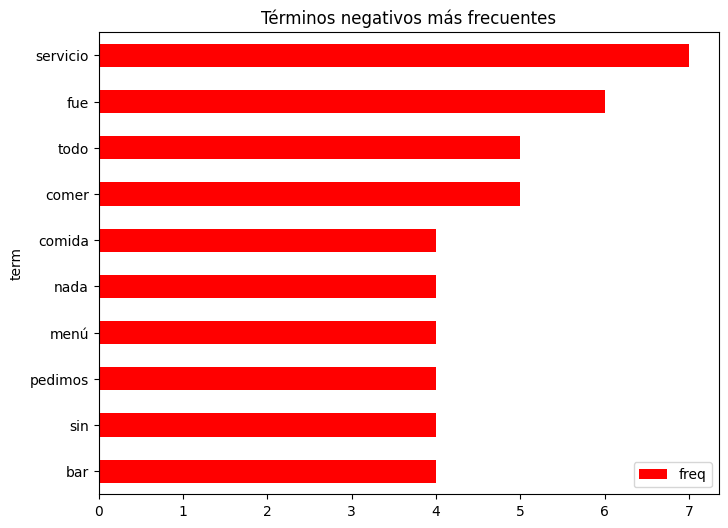

In [6]:
top_pos = pd.read_csv("terminos_positivos.csv")
top_neg = pd.read_csv("terminos_negativos.csv")

top_pos.head(10).plot(kind="barh", x="term", y="freq", figsize=(8,6), color="green")
plt.title("Términos positivos más frecuentes")
plt.gca().invert_yaxis()
plt.show()

top_neg.head(10).plot(kind="barh", x="term", y="freq", figsize=(8,6), color="red")
plt.title("Términos negativos más frecuentes")
plt.gca().invert_yaxis()
plt.show()

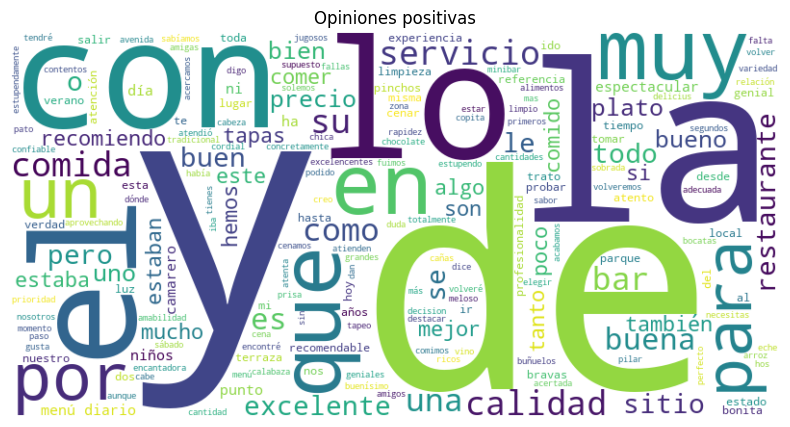

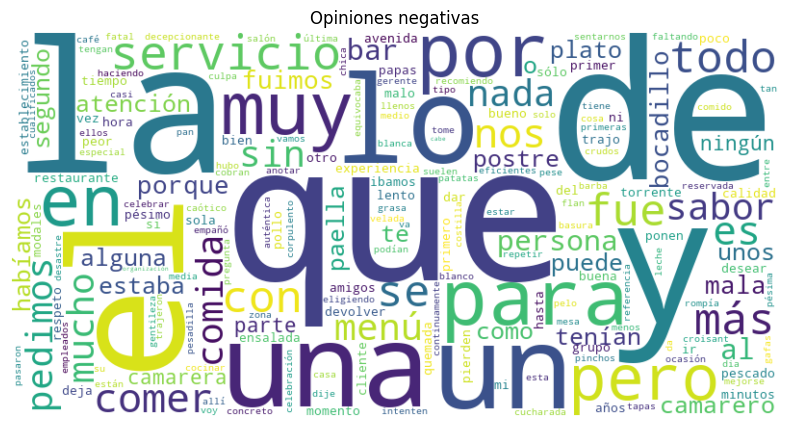

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Asegurar limpieza
df["comentario_clean"] = df["comentario_clean"].fillna("").astype(str)

# Texto combinado
texto_pos = " ".join(df[df["sentiment_label"]=="positivo"]["comentario_clean"].tolist())
texto_neg = " ".join(df[df["sentiment_label"]=="negativo"]["comentario_clean"].tolist())

# Wordclouds
wc_pos = WordCloud(width=800, height=400, background_color="white").generate(texto_pos)
wc_neg = WordCloud(width=800, height=400, background_color="white").generate(texto_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Opiniones positivas")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Opiniones negativas")
plt.show()